# 04c — SHAP Analysis v2

Inputs: best tuned model from `04b_tuning_v2` (falls back to baseline if tuning not run yet), `test_v2.csv`, `selected_features_v2.json`

Generates:
- Global bar plot (mean |SHAP| per feature)
- Beeswarm plot
- Top-3 individual waterfall plots
- SHAP values CSV for dashboard

Key check: elevation/slope should NOT dominate in v2 (unlike v1 where geographic confounding made them top features).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import shap

sns.set_theme(style='whitegrid', font_scale=1.1)
shap.initjs()

PROCESSED  = Path('../data/processed')
OUTPUTS    = Path('../outputs')
MODELS_DIR = Path('../models')
SHAP_DIR   = OUTPUTS / 'shap'
SHAP_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
print('All imports OK')

All imports OK


## 1. Load Data & Best Model

In [2]:
with open(PROCESSED / 'selected_features_v2.json') as f:
    feature_meta = json.load(f)
MODEL_FEATURES = feature_meta['all_model_features']

test = pd.read_csv(PROCESSED / 'test_v2.csv')
X_test = test[MODEL_FEATURES].values
y_test = test['label'].values

# Subsample for SHAP — 2000 points is plenty for global analysis
rng = np.random.default_rng(RANDOM_STATE)
shap_idx = rng.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_shap   = X_test[shap_idx]
y_shap   = y_test[shap_idx]

print(f'Test set   : {X_test.shape}')
print(f'SHAP sample: {X_shap.shape}')
print(f'Features   : {MODEL_FEATURES}')

Test set   : (19392, 19)
SHAP sample: (2000, 19)
Features   : ['elevation', 'slope', 'aspect_cos', 'population_density', 'clay', 'distance_to_road_km', 'distance_to_river_km', 'distance_to_settlement_km', 'lc_20', 'lc_30', 'lc_40', 'lc_50', 'lc_60', 'lc_80', 'lc_90', 'lc_114', 'lc_116', 'lc_124', 'lc_126']


In [3]:
# Load best tuned model; fall back to baseline if tuning not done yet
def load_best_model():
    tuned_path = OUTPUTS / 'v2_tuned_metrics.json'
    if tuned_path.exists():
        with open(tuned_path) as f:
            tuned = json.load(f)
        best = max(tuned, key=lambda r: r['test_roc_auc'])
        name = best['model']
        pkl  = MODELS_DIR / f'{name.lower()}_v2_best.pkl'
        source = 'tuned'
    else:
        with open(OUTPUTS / 'v2_baseline_metrics.json') as f:
            baseline = json.load(f)
        best = max(baseline, key=lambda r: r['test_roc_auc'])
        name = best['model']
        pkl  = MODELS_DIR / f'{name.lower()}_v2_baseline.pkl'
        source = 'baseline'

    with open(pkl, 'rb') as f:
        model = pickle.load(f)
    print(f'Loaded {name} ({source})  pkl={pkl.name}')
    print(f'  Test AUC={best["test_roc_auc"]:.4f}')
    return model, name, source

best_model, best_model_name, model_source = load_best_model()

Loaded RandomForest (tuned)  pkl=randomforest_v2_best.pkl
  Test AUC=0.6976


## 2. Compute SHAP Values

`TreeExplainer` is exact and fast for RF/XGBoost/LightGBM.

In [4]:
print('Computing SHAP values...')
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

# SHAP >= 0.40 returns 3D array (samples, features, classes) for RF;
# older versions return a list [class0, class1]. Handle both.
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv = shap_values[:, :, 1]          # class 1 = fire
elif isinstance(shap_values, list):
    sv = np.array(shap_values[1])      # class 1 = fire
else:
    sv = np.array(shap_values)         # single-output (XGB/LGBM)

assert sv.ndim == 2, f'Expected 2D SHAP array, got shape {sv.shape}'
print(f'SHAP values shape: {sv.shape}  (sample_rows × features)')

mean_abs = np.abs(sv).mean(axis=0)
print('Mean |SHAP| per feature:')
for feat, val in sorted(zip(MODEL_FEATURES, mean_abs.tolist()), key=lambda x: -x[1]):
    print(f'  {feat:35s} {val:.5f}')

Computing SHAP values...


SHAP values shape: (2000, 19)  (sample_rows × features)
Mean |SHAP| per feature:
  clay                                0.05619
  distance_to_settlement_km           0.04749
  elevation                           0.04522
  population_density                  0.03270
  distance_to_river_km                0.03097
  slope                               0.02912
  distance_to_road_km                 0.01329
  lc_40                               0.00966
  lc_20                               0.00482
  aspect_cos                          0.00467
  lc_30                               0.00447
  lc_50                               0.00110
  lc_116                              0.00094
  lc_90                               0.00077
  lc_126                              0.00019
  lc_114                              0.00007
  lc_60                               0.00004
  lc_80                               0.00002
  lc_124                              0.00000


## 3. Global Bar Plot

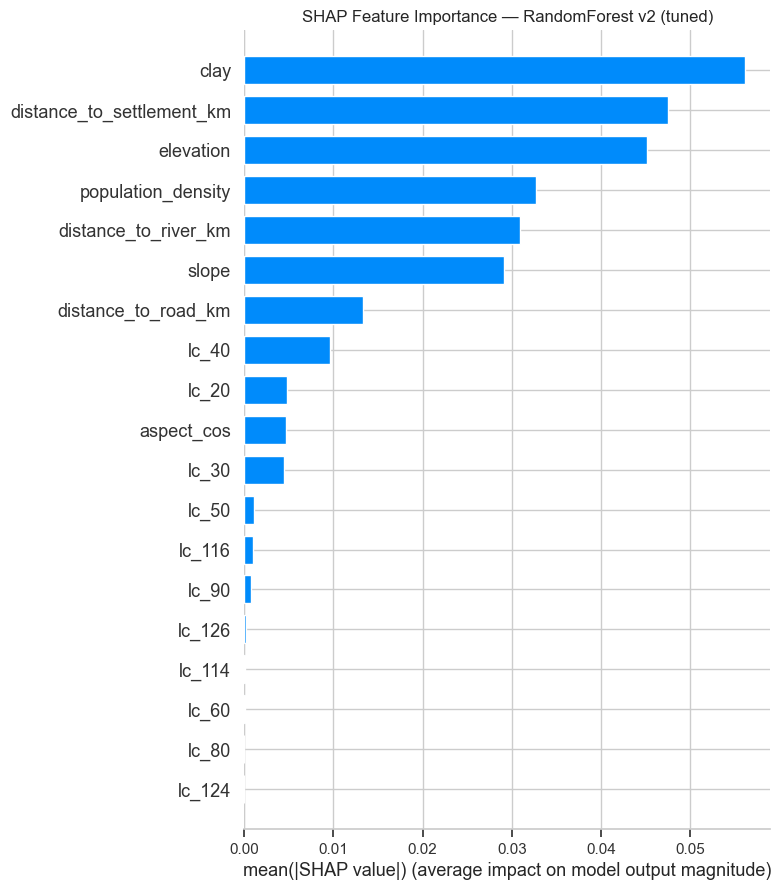

Saved: ../outputs/shap/shap_bar_v2.png


In [5]:
fig, ax = plt.subplots(figsize=(8, 7))
shap.summary_plot(sv, X_shap, feature_names=MODEL_FEATURES,
                  plot_type='bar', show=False, max_display=19)
ax = plt.gca()
ax.set_title(f'SHAP Feature Importance — {best_model_name} v2 ({model_source})', fontsize=12)
plt.tight_layout()
plt.savefig(SHAP_DIR / 'shap_bar_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {SHAP_DIR}/shap_bar_v2.png')

## 4. Beeswarm Plot

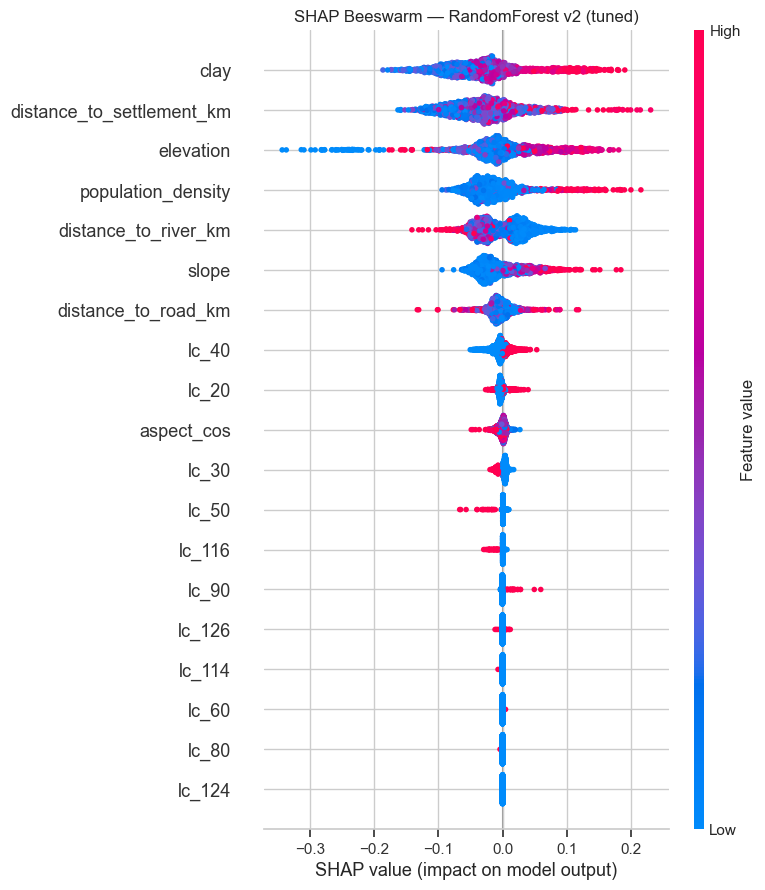

Saved: ../outputs/shap/shap_beeswarm_v2.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(sv, X_shap, feature_names=MODEL_FEATURES,
                  plot_type='dot', show=False, max_display=19)
ax = plt.gca()
ax.set_title(f'SHAP Beeswarm — {best_model_name} v2 ({model_source})', fontsize=12)
plt.tight_layout()
plt.savefig(SHAP_DIR / 'shap_beeswarm_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {SHAP_DIR}/shap_beeswarm_v2.png')

## 5. Top-3 Individual Waterfall Plots

Pick one high-confidence fire, one high-confidence no-fire, one uncertain prediction.

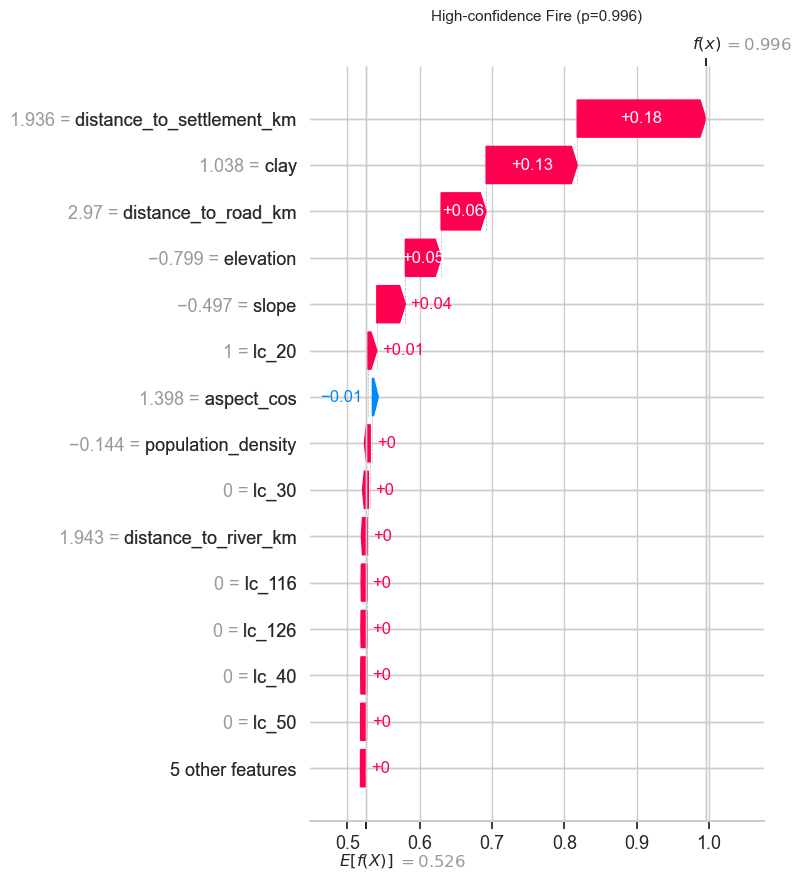

Saved: ../outputs/shap/shap_waterfall_fire_v2.png


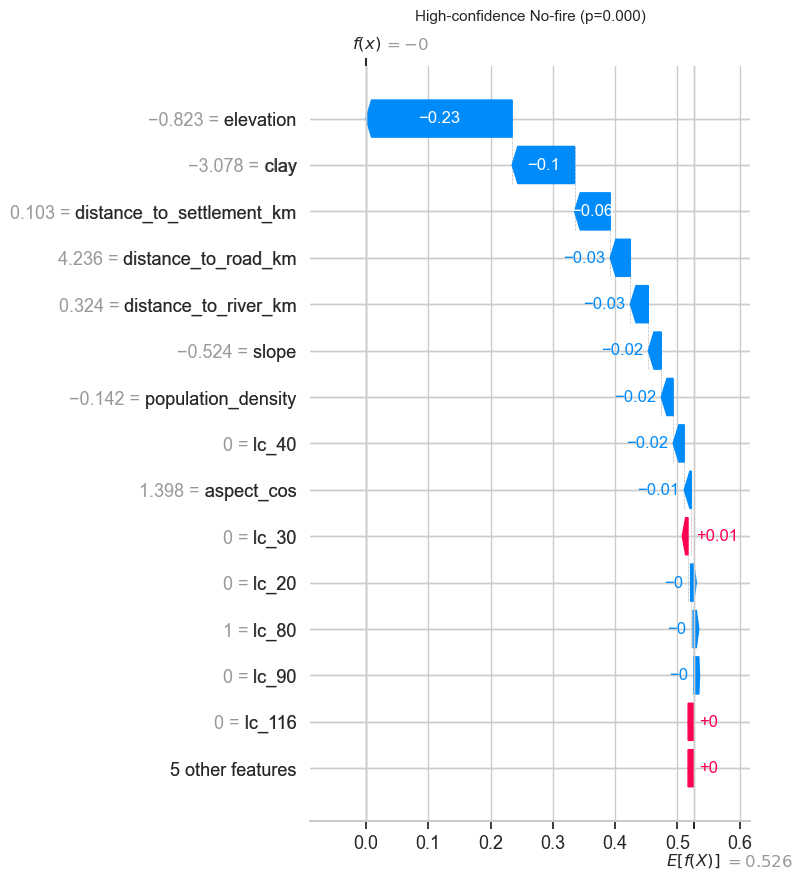

Saved: ../outputs/shap/shap_waterfall_nofire_v2.png


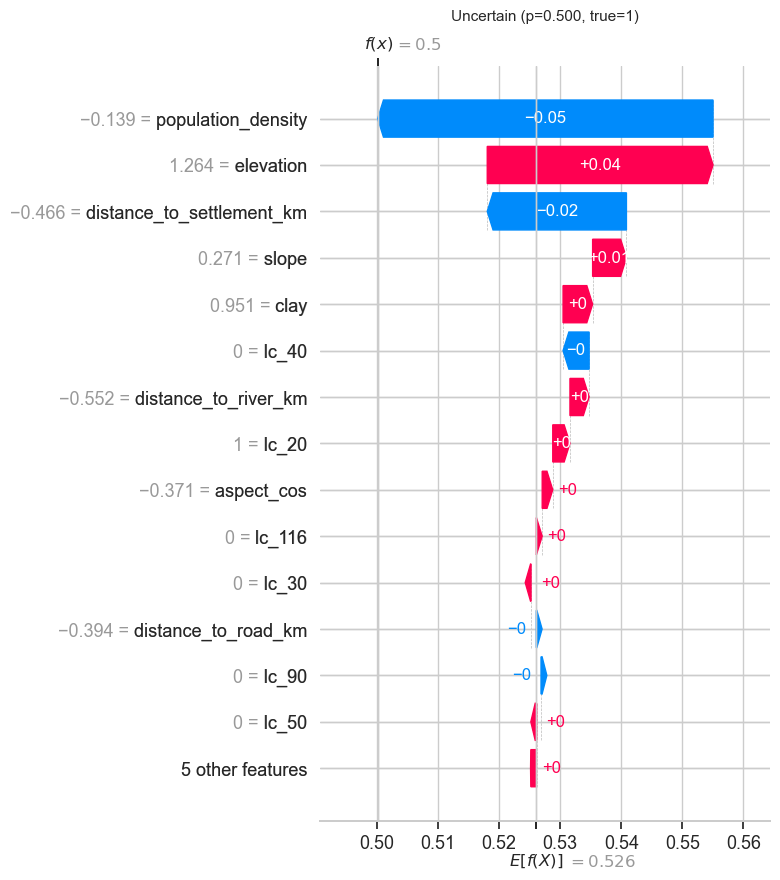

Saved: ../outputs/shap/shap_waterfall_uncertain_v2.png


In [7]:
y_prob_shap = best_model.predict_proba(X_shap)[:, 1]

fire_mask   = y_shap == 1
nofire_mask = y_shap == 0

idx_high_fire   = np.where(fire_mask)[0][np.argmax(y_prob_shap[fire_mask])]
idx_high_nofire = np.where(nofire_mask)[0][np.argmin(y_prob_shap[nofire_mask])]
idx_uncertain   = np.argmin(np.abs(y_prob_shap - 0.5))

samples = [
    (idx_high_fire,   f'High-confidence Fire (p={y_prob_shap[idx_high_fire]:.3f})',   'shap_waterfall_fire_v2.png'),
    (idx_high_nofire, f'High-confidence No-fire (p={y_prob_shap[idx_high_nofire]:.3f})', 'shap_waterfall_nofire_v2.png'),
    (idx_uncertain,   f'Uncertain (p={y_prob_shap[idx_uncertain]:.3f}, true={int(y_shap[idx_uncertain])})', 'shap_waterfall_uncertain_v2.png'),
]

# expected_value may be scalar, list, or 1D array depending on SHAP version
ev = explainer.expected_value
if isinstance(ev, (list, np.ndarray)):
    base_val = float(np.array(ev).ravel()[1])   # class 1
else:
    base_val = float(ev)

for idx, title, fname in samples:
    exp_obj = shap.Explanation(
        values        = sv[idx],
        base_values   = base_val,
        data          = X_shap[idx],
        feature_names = MODEL_FEATURES,
    )
    fig, ax = plt.subplots(figsize=(9, 6))
    shap.waterfall_plot(exp_obj, show=False, max_display=15)
    plt.title(title, fontsize=11, pad=10)
    plt.tight_layout()
    plt.savefig(SHAP_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {SHAP_DIR}/{fname}')

## 6. SHAP Dependence Plots — Top 4 Features

Top 4 features by mean |SHAP|: ['clay', 'distance_to_settlement_km', 'elevation', 'population_density']


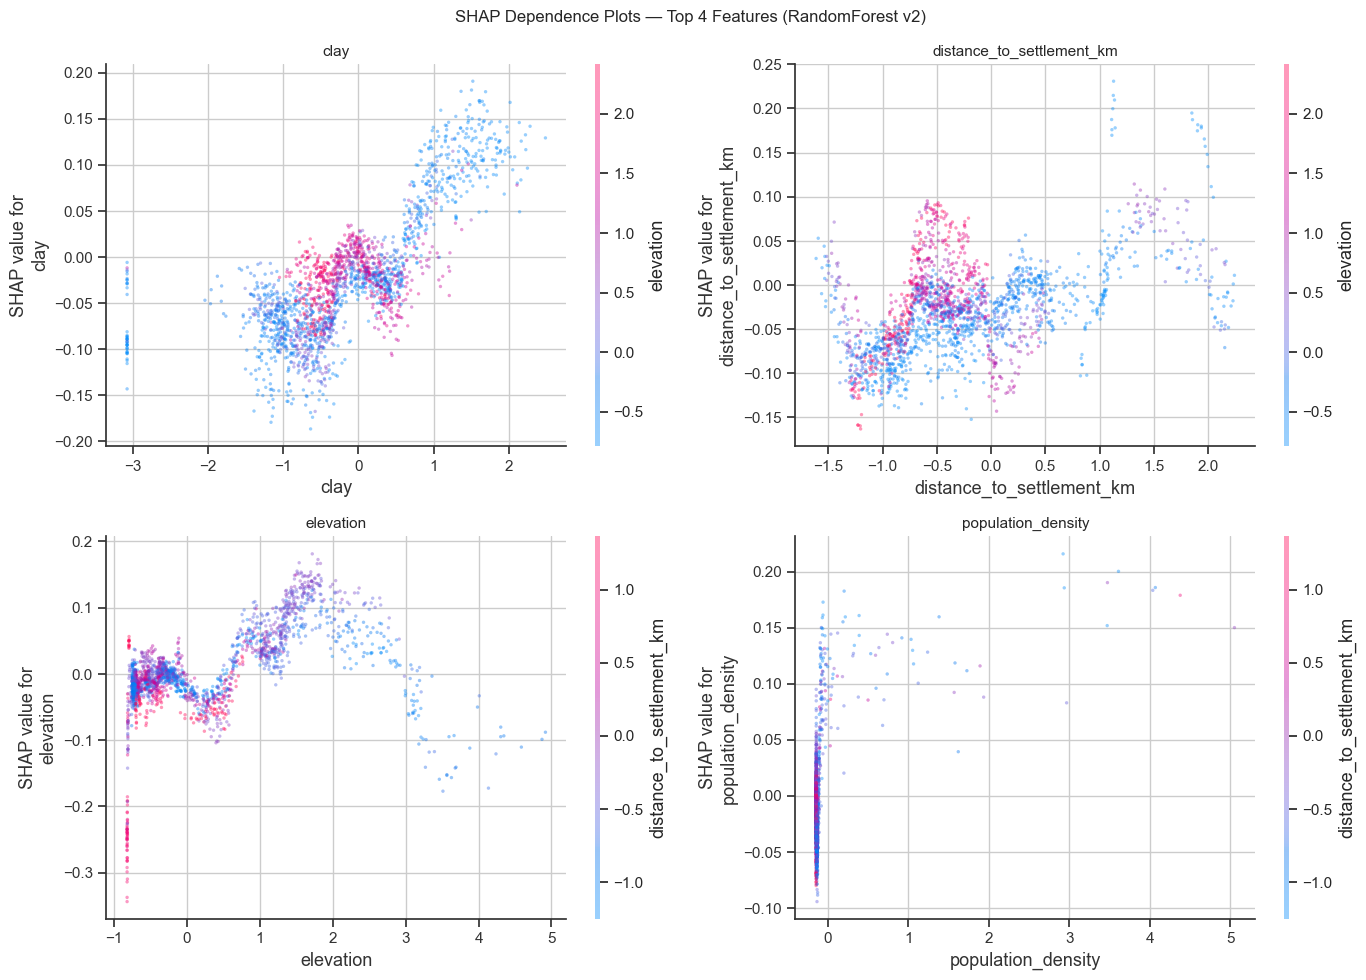

Saved: ../outputs/shap/shap_dependence_top4_v2.png


In [8]:
top4_features = [MODEL_FEATURES[i] for i in np.argsort(mean_abs)[::-1][:4]]
print(f'Top 4 features by mean |SHAP|: {top4_features}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.ravel(), top4_features):
    feat_idx = MODEL_FEATURES.index(feat)
    shap.dependence_plot(
        feat_idx, sv, X_shap,
        feature_names=MODEL_FEATURES,
        ax=ax, show=False, dot_size=6, alpha=0.4
    )
    ax.set_title(feat, fontsize=11)

plt.suptitle(f'SHAP Dependence Plots — Top 4 Features ({best_model_name} v2)', fontsize=12)
plt.tight_layout()
plt.savefig(SHAP_DIR / 'shap_dependence_top4_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {SHAP_DIR}/shap_dependence_top4_v2.png')

## 7. Export SHAP Values for Dashboard

In [9]:
shap_df = pd.DataFrame(sv, columns=MODEL_FEATURES)
shap_df['label']     = y_shap
shap_df['pred_prob'] = y_prob_shap
shap_df.to_csv(SHAP_DIR / 'shap_values_test_v2.csv', index=False)
print(f'Saved: {SHAP_DIR}/shap_values_test_v2.csv  ({shap_df.shape})')

shap_summary_sorted = dict(sorted(
    {feat: float(val) for feat, val in zip(MODEL_FEATURES, mean_abs)}.items(),
    key=lambda x: -x[1]
))
with open(OUTPUTS / 'shap_summary_v2.json', 'w') as f:
    json.dump(shap_summary_sorted, f, indent=2)
print(f'Saved: {OUTPUTS}/shap_summary_v2.json')

Saved: ../outputs/shap/shap_values_test_v2.csv  ((2000, 21))
Saved: ../outputs/shap_summary_v2.json


## 8. Verification

In [10]:
print('=== SHAP V2 VERIFICATION ===')

assert sv.shape == (len(X_shap), len(MODEL_FEATURES)), f'Unexpected SHAP shape: {sv.shape}'
print(f'  [OK] SHAP shape: {sv.shape}')

for fname in ['shap_bar_v2.png', 'shap_beeswarm_v2.png',
               'shap_waterfall_fire_v2.png', 'shap_waterfall_nofire_v2.png',
               'shap_waterfall_uncertain_v2.png', 'shap_dependence_top4_v2.png',
               'shap_values_test_v2.csv']:
    exists = (SHAP_DIR / fname).exists()
    print(f'  [{"OK" if exists else "MISSING"}] {fname}')

assert (OUTPUTS / 'shap_summary_v2.json').exists()
print('  [OK] shap_summary_v2.json')

ranked    = sorted(zip(MODEL_FEATURES, mean_abs), key=lambda x: -x[1])
top3      = [f for f, _ in ranked[:3]]
topo_in_top3 = any(f in top3 for f in ['elevation', 'slope'])
print(f'\n  Top 3 features: {top3}')
if topo_in_top3:
    print('  [WARN] elevation/slope still in top 3 — geographic confounding may persist')
else:
    print('  [OK] elevation/slope NOT dominating top 3 — v2 fix working')

print('\nDone. Next: 04d_evaluation_v2.ipynb')

=== SHAP V2 VERIFICATION ===
  [OK] SHAP shape: (2000, 19)
  [OK] shap_bar_v2.png
  [OK] shap_beeswarm_v2.png
  [OK] shap_waterfall_fire_v2.png
  [OK] shap_waterfall_nofire_v2.png
  [OK] shap_waterfall_uncertain_v2.png
  [OK] shap_dependence_top4_v2.png
  [OK] shap_values_test_v2.csv
  [OK] shap_summary_v2.json

  Top 3 features: ['clay', 'distance_to_settlement_km', 'elevation']
  [WARN] elevation/slope still in top 3 — geographic confounding may persist

Done. Next: 04d_evaluation_v2.ipynb
